In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from weatherdata_rain_wind import WeatherData

In [8]:
save_dir = Path('interpolation_stat')
save_dir.mkdir(exist_ok=True)

In [9]:
grib_path = Path('HARMONIE_AROME_meteo_24hrs/extracted_merged')
first_file = grib_path / "fc2024070912+000GB_UWCW01_N20e_selected.grb"

In [12]:
weather_data = WeatherData(str(grib_path))

In [13]:
# read the coordinates
coordinates_df = pd.read_csv('coordinates_storage/coordinates_20250214_154842.csv')
test_coordinates = list(zip(coordinates_df['latitude'], coordinates_df['longitude']))


In [14]:
test_hours = range(16)

In [15]:
results_data = []
for hour in test_hours:
    print(f"Processing hour {hour}")
    comparison = weather_data.generate_interpolation_comparison(test_coordinates, hour)
    
    # organize the data
    for method in ['ground_truth', 'bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        for param in ['wind_u', 'wind_v', 'rain']:
            if method == 'ground_truth':
                values = comparison[method][param]
            else:
                values = comparison[method][param]
            
            # merge the data
            for i, value in enumerate(values):
                results_data.append({
                    'hour': hour,
                    'method': method,
                    'parameter': param,
                    'value': value,
                    'lat': test_coordinates[i][0],
                    'lon': test_coordinates[i][1]
                })
# convert to DataFrame and save
results_df = pd.DataFrame(results_data)
# results_df.to_csv(save_dir / 'interpolation_results.csv', index=False)

# print(f"Data collection completed. Total samples: {len(results_df)}")
# print(f"Unique coordinates: {len(test_coordinates)}")
# print(f"Time range: {test_hours}")
# print("\nDataFrame head:")
# print(results_df.head())
# print("\nDataFrame info:")
# print(results_df.info())

Processing hour 0


d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\interpolate\_rbf.py:268: LinAlgWarning: Ill-conditioned matrix (rcond=5.34083e-19): result may not be accurate.
  self.nodes = linalg.solve(self.A, self.di)


Processing hour 1
Processing hour 2
Processing hour 3
Processing hour 4
Processing hour 5
Processing hour 6
Processing hour 7
Processing hour 8
Processing hour 9
Processing hour 10
Processing hour 11
Processing hour 12
Processing hour 13
Processing hour 14
Processing hour 15


## 同一地点（阿姆斯特丹）不同的插值方法是否有显著性差异？

In [16]:
def calculate_error_metrics(df, param):
    """计算各种误差指标"""
    # 获取真实值
    truth = df[df['method'] == 'ground_truth']['value'].values
    metrics = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = df[df['method'] == method]['value'].values
        metrics[method] = {
            'MAE': np.mean(np.abs(pred - truth)),
            'RMSE': np.sqrt(np.mean((pred - truth)**2)),
            'R2': stats.pearsonr(truth, pred)[0]**2,
            'Bias': np.mean(pred - truth)
        }
    
    return pd.DataFrame(metrics).T

In [17]:
# 分别计算每个参数的误差统计
for param in ['wind_u', 'wind_v', 'rain']:
    param_data = results_df[results_df['parameter'] == param]
    print(f"\n{param} Error Metrics:")
    print(calculate_error_metrics(param_data, param))


wind_u Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.126039  0.318911  0.996956 -0.001863
idw       0.121071  0.319755  0.996941 -0.008320
kriging   0.344859  0.819505  0.980039 -0.050829
spline    0.136757  0.334215  0.996656  0.002056
rbf       0.498675  1.521677  0.935120  0.025259

wind_v Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.140426  0.277775  0.985186 -0.000224
idw       0.138717  0.284794  0.984737  0.003298
kriging   0.382873  0.679219  0.914180 -0.020804
spline    0.149259  0.288771  0.983952  0.007267
rbf       0.482379  1.098809  0.804391  0.000393

rain Error Metrics:
               MAE      RMSE        R2      Bias
bilinear  0.075917  0.269602  0.994424 -0.000704
idw       0.069157  0.262739  0.994701  0.004461
kriging   0.213513  0.663905  0.968109 -0.030653
spline    0.078079  0.275342  0.994199  0.005708
rbf       0.209390  0.818692  0.952373  0.019001


In [18]:
# 2. 可视化分析
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表样式
plt.style.use('default')  # 使用默认样式
sns.set_theme(style="whitegrid")  # 使用seaborn的网格样式

# 创建子图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 设置颜色方案
colors = sns.color_palette("husl", n_colors=6)

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 箱线图比较
    sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
    
    # 设置标题和标签
    axes[i].set_title(f'{param} Distribution by Method', fontsize=12, pad=10)
    axes[i].set_xlabel('Interpolation Method', fontsize=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    
    # 添加网格
    axes[i].grid(True, linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()

# 保存图片
plt.savefig(save_dir / 'distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# 添加更多的可视化分析
# 1. 误差分布图
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 计算每种方法的误差
    truth = param_data[param_data['method'] == 'ground_truth']['value'].values
    errors = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = param_data[param_data['method'] == method]['value'].values
        errors[method] = pred - truth
    
    # 绘制误差分布
    error_data = pd.DataFrame(errors)
    sns.violinplot(data=error_data, ax=axes[i], palette=colors)
    
    axes[i].set_title(f'{param} Error Distribution', fontsize=12, pad=10)
    axes[i].set_xlabel('Method', fontsize=10)
    axes[i].set_ylabel('Error', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # 添加零线
    axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(save_dir / 'error_distribution.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. 散点图比较（真实值vs预测值）
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    truth = param_data[param_data['method'] == 'ground_truth']['value'].values
    
    for j, method in enumerate(['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
        pred = param_data[param_data['method'] == method]['value'].values
        
        # 绘制散点图
        axes[i, j].scatter(truth, pred, alpha=0.1, s=1)
        
        # 添加对角线
        min_val = min(truth.min(), pred.min())
        max_val = max(truth.max(), pred.max())
        axes[i, j].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
        
        axes[i, j].set_title(f'{param} - {method}')
        axes[i, j].set_xlabel('Ground Truth')
        axes[i, j].set_ylabel('Predicted')
        axes[i, j].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(save_dir / 'scatter_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

C:\Users\96454\AppData\Local\Temp\ipykernel_38136\1640836246.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\1640836246.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\1640836246.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=param_data, x='method', y='value', ax=axes[i], palette=colors)
C

In [19]:
# time series analysis
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
    param_data = results_df[results_df['parameter'] == param]
    
    # 计算每个小时的平均值
    hourly_means = param_data.groupby(['hour', 'method'])['value'].mean().unstack()
    
    # 绘制时间序列
    hourly_means.plot(ax=axes[i], marker='o')
    axes[i].set_title(f'{param} Temporal Evolution')
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig(save_dir / 'temporal_evolution.png')
plt.close()

 

In [20]:
import random
def spatial_correlation_optimized(df, param, sample_size=500):
    """
    计算空间自相关性（处理常数值情况）
    Args:
        df: 数据框
        param: 参数名称
        sample_size: 采样点数量
    Returns:
        correlations: 字典，包含每种方法的空间相关性
        valid: 布尔值，表示计算是否有效
    """
    from scipy.spatial.distance import pdist
    
    # 只处理特定参数的数据
    param_data = df[df['parameter'] == param].copy()
    
    # 获取唯一的时间点
    unique_hours = param_data['hour'].unique()
    
    # 尝试找到一个非常数值的时间点
    valid_hour = None
    for hour in unique_hours:
        hour_data = param_data[param_data['hour'] == hour]
        if hour_data['value'].nunique() > 1:
            valid_hour = hour
            break
    
    if valid_hour is None:
        print(f"Warning: All values are constant for {param}")
        return None, False
        
    param_data = param_data[param_data['hour'] == valid_hour]
    
    # 获取唯一的坐标点
    unique_coords = param_data[['lat', 'lon']].drop_duplicates()
    
    # 随机采样坐标点
    if len(unique_coords) > sample_size:
        sampled_indices = random.sample(range(len(unique_coords)), sample_size)
        sampled_coords = unique_coords.iloc[sampled_indices]
    else:
        sampled_coords = unique_coords
    
    # 计算坐标点之间的距离
    coords_array = sampled_coords[['lat', 'lon']].values
    distances = pdist(coords_array)
    
    # 计算每种方法的空间相关性
    correlations = {}
    for method in ['ground_truth', 'bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        method_data = param_data[param_data['method'] == method]
        method_data = method_data.merge(sampled_coords, on=['lat', 'lon'])
        values = method_data['value'].values
        
        # 检查是否有变化的值
        if np.std(values) < 1e-10:  # 使用小阈值检查是否为常数
            correlations[method] = np.nan
            continue
            
        value_diffs = pdist(values.reshape(-1, 1))
        try:
            corr = stats.spearmanr(distances, value_diffs)[0]
            correlations[method] = corr
        except:
            correlations[method] = np.nan
            
    return correlations, True

# 设置随机种子
np.random.seed(42)
random.seed(42)

# 对每个参数计算空间相关性
for param in ['wind_u', 'wind_v', 'rain']:
    print(f"\n{param} Spatial Correlation:")
    
    # 多次计算取平均
    n_iterations = 5
    all_correlations = []
    
    for i in range(n_iterations):
        correlations, valid = spatial_correlation_optimized(results_df, param)
        if valid and correlations is not None:
            all_correlations.append(pd.Series(correlations))
    
    if len(all_correlations) > 0:
        # 计算平均相关性
        mean_correlations = pd.DataFrame(all_correlations).mean()
        
        # 创建更易读的输出
        corr_df = pd.DataFrame({'Spatial Correlation': mean_correlations})
        print(corr_df)
        
        # 可视化
        plt.figure(figsize=(10, 6))
        plt.bar(mean_correlations.index, mean_correlations.values)
        plt.title(f'Average Spatial Correlation for {param}\n(over {len(all_correlations)} valid iterations)')
        plt.xticks(rotation=45)
        plt.ylabel('Correlation Coefficient')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(save_dir / f'spatial_correlation_{param}.png')
        plt.close()
    else:
        print(f"No valid correlations could be computed for {param}")


wind_u Spatial Correlation:
              Spatial Correlation
ground_truth             0.000941
bilinear                 0.001751
idw                      0.002301
kriging                  0.004538
spline                  -0.000145
rbf                      0.013000

wind_v Spatial Correlation:
              Spatial Correlation
ground_truth             0.003870
bilinear                 0.002209
idw                      0.003708
kriging                  0.000399
spline                   0.002333
rbf                      0.005129

rain Spatial Correlation:
              Spatial Correlation
ground_truth            -0.000239
bilinear                 0.000735
idw                      0.001626
kriging                  0.003035
spline                   0.000579
rbf                     -0.002864


In [21]:
# 5. 统计显著性检验
def statistical_tests(df, param):
    """进行统计显著性检验"""
    from scipy import stats
    
    truth = df[df['method'] == 'ground_truth']['value'].values
    results = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = df[df['method'] == method]['value'].values
        # KS检验
        ks_stat = stats.ks_2samp(truth, pred)
        # t检验
        t_stat = stats.ttest_ind(truth, pred)
        
        results[method] = {
            'KS_stat': ks_stat.statistic,
            'KS_pvalue': ks_stat.pvalue,
            't_stat': t_stat.statistic,
            't_pvalue': t_stat.pvalue
        }
    
    return pd.DataFrame(results).T

# 进行统计检验
for param in ['wind_u', 'wind_v', 'rain']:
    param_data = results_df[results_df['parameter'] == param]
    print(f"\n{param} Statistical Tests:")
    print(statistical_tests(param_data, param))


wind_u Statistical Tests:
           KS_stat     KS_pvalue    t_stat  t_pvalue
bilinear  0.011475  3.549253e-04  0.058447  0.953393
idw       0.015106  6.330474e-07  0.260843  0.794214
kriging   0.032532  1.455703e-30  1.593403  0.111072
spline    0.012100  1.349453e-04 -0.064419  0.948637
rbf       0.037979  1.672097e-41 -0.778027  0.436554

wind_v Statistical Tests:
           KS_stat      KS_pvalue    t_stat  t_pvalue
bilinear  0.015152   5.780912e-07  0.017928  0.985697
idw       0.018417   4.372967e-10 -0.265578  0.790564
kriging   0.066666  4.610625e-127  1.736245  0.082523
spline    0.012253   1.057653e-04 -0.578878  0.562672
rbf       0.049240   1.743995e-69 -0.029853  0.976184

rain Statistical Tests:
           KS_stat      KS_pvalue    t_stat  t_pvalue
bilinear  0.039597   4.458733e-45  0.035443  0.971726
idw       0.060226  9.185936e-104 -0.224453  0.822405
kriging   0.130280   0.000000e+00  1.585188  0.112926
spline    0.072098  1.452529e-148 -0.286167  0.774751
rbf      

In [22]:
def calculate_comprehensive_metrics(df, param):
    """计算全面的评估指标"""
    # 获取真实值
    truth = df[df['method'] == 'ground_truth']['value'].values
    metrics = {}
    
    for method in ['bilinear', 'idw', 'kriging', 'spline', 'rbf']:
        pred = df[df['method'] == method]['value'].values
        
        # 1. 基础误差指标
        mae = np.mean(np.abs(pred - truth))
        rmse = np.sqrt(np.mean((pred - truth)**2))
        bias = np.mean(pred - truth)
        
        # 2. 相关性指标
        r2 = stats.pearsonr(truth, pred)[0]**2
        spearman_corr = stats.spearmanr(truth, pred)[0]
        
        # 3. 相对误差指标
        mape = np.mean(np.abs((pred - truth) / (truth + 1e-10))) * 100  # 添加小值避免除零
        rrmse = rmse / np.mean(np.abs(truth)) * 100
        
        # 4. 一致性指标
        nash_sutcliffe = 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2)
        index_agreement = 1 - np.sum((pred - truth)**2) / np.sum((np.abs(pred - np.mean(truth)) + np.abs(truth - np.mean(truth)))**2)
        
        # 5. 分布相似性指标
        ks_stat = stats.ks_2samp(truth, pred).statistic
        
        # 6. 极值保持指标
        max_error = np.abs(np.max(pred) - np.max(truth)) / np.max(truth) * 100
        min_error = np.abs(np.min(pred) - np.min(truth)) / (np.abs(np.min(truth)) + 1e-10) * 100
        
        # 7. 方差保持指标
        variance_ratio = np.var(pred) / np.var(truth)
        
        metrics[method] = {
            # 基础误差
            'MAE': mae,
            'RMSE': rmse,
            'Bias': bias,
            
            # 相关性
            'R2': r2,
            'Spearman_Corr': spearman_corr,
            
            # 相对误差
            'MAPE(%)': mape,
            'RRMSE(%)': rrmse,
            
            # 一致性
            'Nash_Sutcliffe': nash_sutcliffe,
            'Index_Agreement': index_agreement,
            
            # 分布相似性
            'KS_statistic': ks_stat,
            
            # 极值保持
            'Max_Error(%)': max_error,
            'Min_Error(%)': min_error,
            
            # 方差保持
            'Variance_Ratio': variance_ratio
        }
    
    return pd.DataFrame(metrics).T

# 对每个参数计算全面的评估指标
for param in ['wind_u', 'wind_v', 'rain']:
    print(f"\n{param} Comprehensive Evaluation Metrics:")
    param_data = results_df[results_df['parameter'] == param]
    metrics_df = calculate_comprehensive_metrics(param_data, param)
    
    # 设置显示格式
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    print(metrics_df)
    
    # 保存结果
    metrics_df.to_csv(save_dir / f'{param}_comprehensive_metrics.csv')


wind_u Comprehensive Evaluation Metrics:
            MAE   RMSE    Bias     R2  Spearman_Corr  MAPE(%)  RRMSE(%)  \
bilinear 0.1260 0.3189 -0.0019 0.9970         0.9957   4.2364    5.8023   
idw      0.1211 0.3198 -0.0083 0.9969         0.9958   3.9965    5.8177   
kriging  0.3449 0.8195 -0.0508 0.9800         0.9798  10.0446   14.9103   
spline   0.1368 0.3342  0.0021 0.9967         0.9955   4.7753    6.0808   
rbf      0.4987 1.5217  0.0253 0.9351         0.9676  17.7054   27.6858   

          Nash_Sutcliffe  Index_Agreement  KS_statistic  Max_Error(%)  \
bilinear          0.9970           0.9992        0.0115        7.3387   
idw               0.9969           0.9992        0.0151        7.3236   
kriging           0.9799           0.9949        0.0325        8.9449   
spline            0.9967           0.9992        0.0121        0.1006   
rbf               0.9307           0.9830        0.0380      160.0609   

          Min_Error(%)  Variance_Ratio  
bilinear        2.5904     

## 验证idw和bilinear方式在不同地点的显著性差异

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [5]:
new_coords = pd.read_csv('coordinates_storage/coordinates_20250217_171722.csv')

In [23]:
def compare_regions(results_df, new_coords, methods=['bilinear', 'idw']):
    """
    比较不同区域的插值效果
    """
    # 将坐标分为不同区域（例如：按照经纬度四等分）
    lat_bins = 2
    lon_bins = 2
    
    new_coords['lat_region'] = pd.qcut(new_coords['latitude'], lat_bins, labels=['South', 'North'])
    new_coords['lon_region'] = pd.qcut(new_coords['longitude'], lon_bins, labels=['West', 'East'])
    
    # 存储结果
    region_metrics = {}
    
    for param in ['wind_u', 'wind_v', 'rain']:
        param_data = results_df[results_df['parameter'] == param]
        
        for lat_region in ['South', 'North']:
            for lon_region in ['West', 'East']:
                region_name = f"{lat_region}_{lon_region}"
                
                # 获取该区域的坐标
                region_coords = new_coords[
                    (new_coords['lat_region'] == lat_region) & 
                    (new_coords['lon_region'] == lon_region)
                ]
                
                # 计算该区域的评估指标
                for method in methods:
                    key = f"{param}_{method}_{region_name}"
                    region_metrics[key] = calculate_region_metrics(
                        param_data, 
                        method, 
                        region_coords[['latitude', 'longitude']].values
                    )
    
    return pd.DataFrame(region_metrics).T

In [24]:
def calculate_region_metrics(param_data, method, region_coords):
    """
    计算特定区域的评估指标
    """
    # 筛选该区域的数据
    region_data = param_data[
        param_data['method'].isin([method, 'ground_truth'])
    ]
    
    # 获取真实值和预测值
    truth = region_data[region_data['method'] == 'ground_truth']['value'].values
    pred = region_data[region_data['method'] == method]['value'].values
    
    return {
        'MAE': np.mean(np.abs(pred - truth)),
        'RMSE': np.sqrt(np.mean((pred - truth)**2)),
        'R2': stats.pearsonr(truth, pred)[0]**2,
        'Bias': np.mean(pred - truth),
        'Nash_Sutcliffe': 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2)
    }

In [25]:
# 执行区域比较
region_comparison = compare_regions(results_df, new_coords)

In [27]:
# 可视化结果
def plot_regional_comparison(region_comparison, metric='RMSE'):
    plt.figure(figsize=(15, 8))
    
    # 重塑数据用于可视化
    plot_data = []
    for idx, row in region_comparison.iterrows():
        param, method, region = idx.split('_', 2)
        plot_data.append({
            'Parameter': param,
            'Method': method,
            'Region': region,
            metric: row[metric]
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # 创建分面图
    g = sns.FacetGrid(plot_df, col='Parameter', height=6, aspect=1.2)
    g.map_dataframe(sns.barplot, x='Region', y=metric, hue='Method')
    g.add_legend()
    plt.tight_layout()
    
    # 保存图片
    plt.savefig(save_dir / f'regional_comparison_{metric}.png')
    plt.close()

In [28]:
# 为不同指标创建可视化
for metric in ['MAE', 'RMSE', 'R2', 'Nash_Sutcliffe']:
    plot_regional_comparison(region_comparison, metric)

d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette=

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [32]:
def statistical_test_regions(region_comparison):
    """
    对不同区域间的差异进行显著性检验（改进版）
    """
    for param in ['wind_u', 'wind_v', 'rain']:
        for method in ['bilinear', 'idw']:
            print(f"\nStatistical tests for {param} - {method}:")
            
            # 提取各区域的数据
            regions_data = {}
            for region in ['South_West', 'South_East', 'North_West', 'North_East']:
                key = f"{param}_{method}_{region}"
                if key in region_comparison.index:
                    regions_data[region] = region_comparison.loc[key]
            
            # 打印诊断信息
            print("\nData available for regions:")
            for region, data in regions_data.items():
                print(f"{region}:")
                print(data)
            
            try:
                # 检查是否有足够的数据进行ANOVA
                if len(regions_data) >= 2:  # 需要至少两组数据
                    # 准备ANOVA数据
                    anova_data = [data['RMSE'] for data in regions_data.values()]
                    
                    # 检查数据是否包含非NaN值
                    if all(not np.isnan(x).all() for x in anova_data):
                        # 执行ANOVA
                        f_stat, p_value = stats.f_oneway(*anova_data)
                        print(f"\nANOVA test results:")
                        print(f"F-statistic = {f_stat:.4f}")
                        print(f"p-value = {p_value:.4f}")
                        
                        # 解释结果
                        if p_value < 0.05:
                            print("Result: Significant differences exist between regions")
                        else:
                            print("Result: No significant differences between regions")
                    else:
                        print("\nWarning: Data contains NaN values")
                else:
                    print("\nWarning: Not enough valid regions for comparison")
            except Exception as e:
                print(f"\nError in statistical test: {str(e)}")
            
            # 添加描述性统计
            print("\nDescriptive statistics for RMSE by region:")
            stats_df = pd.DataFrame(regions_data).T
            print(stats_df['RMSE'].describe())

# 执行改进的统计检验
statistical_test_regions(region_comparison)


Statistical tests for wind_u - bilinear:

Data available for regions:
South_West:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_South_West, dtype: float64
South_East:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_South_East, dtype: float64
North_West:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_North_West, dtype: float64
North_East:
MAE               0.1260
RMSE              0.3189
R2                0.9970
Bias             -0.0019
Nash_Sutcliffe    0.9970
Name: wind_u_bilinear_North_East, dtype: float64

ANOVA test results:
F-statistic = nan
p-value = nan
Result: No significant differences between regions

Descriptive statistics for RMSE by region:
count   4.0000
mean    0.3189
std    

d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\3741993826.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*anova_data)
d:\softwares\Anaconda\envs\myenv_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:567: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\96454\AppData\Local\Temp\ipykernel_38136\3741993826.py:31: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_onew

In [33]:
def compare_all_methods(results_df, new_coords, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    比较所有插值方法在不同区域的表现
    """
    # 将坐标分为不同区域
    lat_bins = 2
    lon_bins = 2
    
    new_coords['lat_region'] = pd.qcut(new_coords['latitude'], lat_bins, labels=['South', 'North'])
    new_coords['lon_region'] = pd.qcut(new_coords['longitude'], lon_bins, labels=['West', 'East'])
    
    # 存储结果
    region_metrics = {}
    
    for param in ['wind_u', 'wind_v', 'rain']:
        print(f"\n{param} Regional Analysis:")
        param_data = results_df[results_df['parameter'] == param]
        
        for method in methods:
            for lat_region in ['South', 'North']:
                for lon_region in ['West', 'East']:
                    region_name = f"{lat_region}_{lon_region}"
                    
                    # 获取该区域的坐标
                    region_coords = new_coords[
                        (new_coords['lat_region'] == lat_region) & 
                        (new_coords['lon_region'] == lon_region)
                    ]
                    
                    # 计算该区域的评估指标
                    key = f"{param}_{method}_{region_name}"
                    metrics = calculate_region_metrics(
                        param_data, 
                        method, 
                        region_coords[['latitude', 'longitude']].values
                    )
                    region_metrics[key] = metrics
                    
                    # 打印详细结果
                    print(f"\n{method.upper()} - {region_name}:")
                    for metric, value in metrics.items():
                        print(f"{metric}: {value:.4f}")
    
    return pd.DataFrame(region_metrics).T

def calculate_region_metrics(param_data, method, region_coords):
    """
    计算特定区域的评估指标
    """
    # 筛选该区域的数据
    region_data = param_data[
        param_data['method'].isin([method, 'ground_truth'])
    ]
    
    # 获取真实值和预测值
    truth = region_data[region_data['method'] == 'ground_truth']['value'].values
    pred = region_data[region_data['method'] == method]['value'].values
    
    return {
        'MAE': np.mean(np.abs(pred - truth)),
        'RMSE': np.sqrt(np.mean((pred - truth)**2)),
        'R2': stats.pearsonr(truth, pred)[0]**2,
        'Bias': np.mean(pred - truth),
        'Nash_Sutcliffe': 1 - np.sum((pred - truth)**2) / np.sum((truth - np.mean(truth))**2),
        'MAPE': np.mean(np.abs((pred - truth) / (truth + 1e-10))) * 100
    }

# 执行比较分析
region_comparison = compare_all_methods(results_df, new_coords)

# 创建可视化比较
def plot_method_comparison(region_comparison, metric='RMSE'):
    """
    创建方法比较的可视化
    """
    plt.figure(figsize=(15, 10))
    
    # 准备数据
    plot_data = []
    for idx, row in region_comparison.iterrows():
        param, method, region = idx.split('_', 2)
        plot_data.append({
            'Parameter': param,
            'Method': method,
            'Region': region,
            metric: row[metric]
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # 创建子图
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, param in enumerate(['wind_u', 'wind_v', 'rain']):
        param_data = plot_df[plot_df['Parameter'] == param]
        
        sns.barplot(data=param_data, x='Region', y=metric, 
                   hue='Method', ax=axes[i])
        
        axes[i].set_title(f'{param} - {metric}')
        axes[i].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.savefig(save_dir / f'all_methods_comparison_{metric}.png')
    plt.close()

# 为不同指标创建可视化
for metric in ['RMSE', 'MAE', 'R2', 'Nash_Sutcliffe', 'MAPE']:
    plot_method_comparison(region_comparison, metric)

# 计算综合评分
def calculate_overall_score(region_comparison):
    """
    计算每种方法的综合评分
    """
    methods = ['bilinear', 'idw', 'kriging', 'spline', 'rbf']
    params = ['wind_u', 'wind_v', 'rain']
    metrics = ['RMSE', 'MAE', 'R2', 'Nash_Sutcliffe']
    
    scores = {}
    
    for method in methods:
        method_data = region_comparison[
            region_comparison.index.str.contains(method)
        ]
        
        # 计算平均指标
        avg_metrics = method_data[metrics].mean()
        
        # 标准化得分（R2和Nash_Sutcliffe越大越好，RMSE和MAE越小越好）
        score = (avg_metrics['R2'] + avg_metrics['Nash_Sutcliffe'] - 
                avg_metrics['RMSE']/avg_metrics['RMSE'].max() - 
                avg_metrics['MAE']/avg_metrics['MAE'].max())
        
        scores[method] = score
    
    return pd.Series(scores).sort_values(ascending=False)

# 打印综合评分
print("\nOverall Method Ranking:")
print(calculate_overall_score(region_comparison))


wind_u Regional Analysis:

BILINEAR - South_West:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - South_East:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - North_West:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

BILINEAR - North_East:
MAE: 0.1260
RMSE: 0.3189
R2: 0.9970
Bias: -0.0019
Nash_Sutcliffe: 0.9970
MAPE: 4.2364

IDW - South_West:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - South_East:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - North_West:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

IDW - North_East:
MAE: 0.1211
RMSE: 0.3198
R2: 0.9969
Bias: -0.0083
Nash_Sutcliffe: 0.9969
MAPE: 3.9965

KRIGING - South_West:
MAE: 0.3449
RMSE: 0.8195
R2: 0.9800
Bias: -0.0508
Nash_Sutcliffe: 0.9799
MAPE: 10.0446

KR

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

## 时间序列分析


WIND_U Time Series Analysis:

1. Basic Statistics:
Ground Truth:
Max: 12.3048
Min: -10.8914
Mean: 2.3994
Std: 5.7791

Peak Time: 6
Trough Time: 7

2. Peak Analysis by Method:

BILINEAR:
Max: 11.4018
Min: -10.6093
Mean: 2.3975
Std: 5.7634
Peak Time: 14
Trough Time: 7
Peak Value Error (%): -7.34
Trough Value Error (%): 2.59

IDW:
Max: 11.4036
Min: -10.4721
Mean: 2.3911
Std: 5.7687
Peak Time: 14
Trough Time: 7
Peak Value Error (%): -7.32
Trough Value Error (%): 3.85

KRIGING:
Max: 11.2042
Min: -9.5081
Mean: 2.3486
Std: 5.7697
Peak Time: 14
Trough Time: 7
Peak Value Error (%): -8.94
Trough Value Error (%): 12.70

SPLINE:
Max: 12.3172
Min: -10.7506
Mean: 2.4015
Std: 5.7747
Peak Time: 6
Trough Time: 7
Peak Value Error (%): 0.10
Trough Value Error (%): 1.29

RBF:
Max: 32.0000
Min: -32.0000
Mean: 2.4247
Std: 5.9733
Peak Time: 6
Trough Time: 6
Peak Value Error (%): 160.06
Trough Value Error (%): -193.81


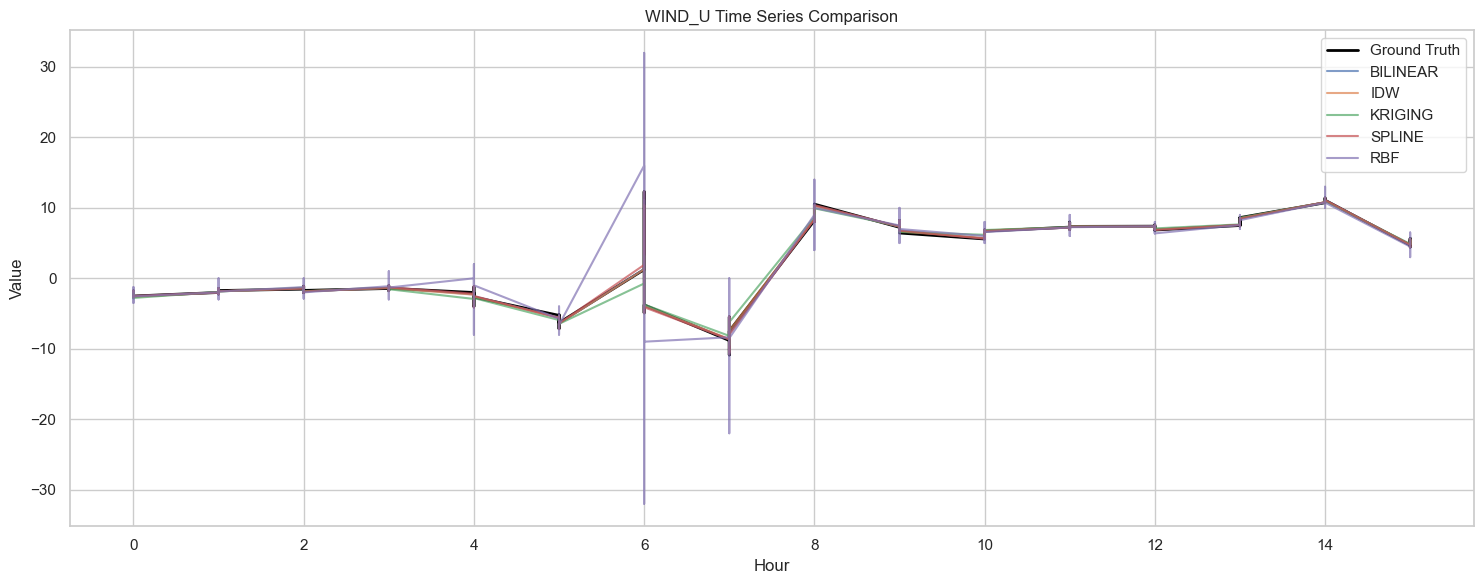


3. Statistical Tests:

BILINEAR:
KS-test: statistic=0.0115, p-value=0.0004
Mann-Whitney U test: statistic=2150700531.0000, p-value=0.6386

IDW:
KS-test: statistic=0.0151, p-value=0.0000
Mann-Whitney U test: statistic=2153561063.0000, p-value=0.3749

KRIGING:
KS-test: statistic=0.0325, p-value=0.0000
Mann-Whitney U test: statistic=2164089255.0000, p-value=0.0153

SPLINE:
KS-test: statistic=0.0121, p-value=0.0001
Mann-Whitney U test: statistic=2150619603.0000, p-value=0.6471

RBF:
KS-test: statistic=0.0380, p-value=0.0000
Mann-Whitney U test: statistic=2144344430.0000, p-value=0.6467

WIND_V Time Series Analysis:

1. Basic Statistics:
Ground Truth:
Max: 9.0186
Min: -2.9166
Mean: 3.9797
Std: 2.2783

Peak Time: 15
Trough Time: 9

2. Peak Analysis by Method:

BILINEAR:
Max: 9.0202
Min: -2.7770
Mean: 3.9795
Std: 2.2450
Peak Time: 15
Trough Time: 9
Peak Value Error (%): 0.02
Trough Value Error (%): 4.79

IDW:
Max: 9.0185
Min: -2.7850
Mean: 3.9830
Std: 2.2175
Peak Time: 15
Trough Time: 9
Peak

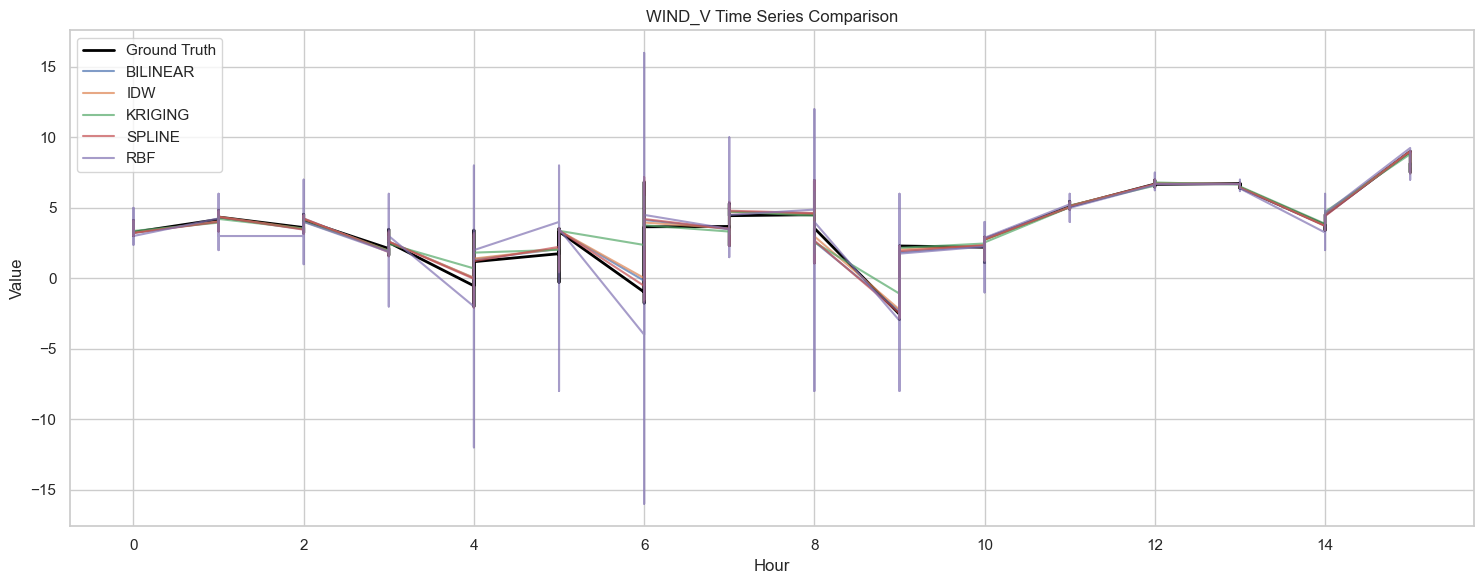


3. Statistical Tests:

BILINEAR:
KS-test: statistic=0.0152, p-value=0.0000
Mann-Whitney U test: statistic=2153411121.0000, p-value=0.3868

IDW:
KS-test: statistic=0.0184, p-value=0.0000
Mann-Whitney U test: statistic=2153115844.0000, p-value=0.4109

KRIGING:
KS-test: statistic=0.0667, p-value=0.0000
Mann-Whitney U test: statistic=2182193130.0000, p-value=0.0000

SPLINE:
KS-test: statistic=0.0123, p-value=0.0001
Mann-Whitney U test: statistic=2145388231.0000, p-value=0.7597

RBF:
KS-test: statistic=0.0492, p-value=0.0000
Mann-Whitney U test: statistic=2131046510.0000, p-value=0.0164

RAIN Time Series Analysis:

1. Basic Statistics:
Ground Truth:
Max: 16.3721
Min: 0.0000
Mean: 1.2857
Std: 3.6068

Peak Time: 7
Trough Time: 0

2. Peak Analysis by Method:

BILINEAR:
Max: 16.3505
Min: 0.0000
Mean: 1.2850
Std: 3.5843
Peak Time: 7
Trough Time: 0
Peak Value Error (%): -0.13
Trough Value Error (%): 0.00

IDW:
Max: 16.3658
Min: 0.0000
Mean: 1.2902
Std: 3.5884
Peak Time: 7
Trough Time: 0
Peak Val

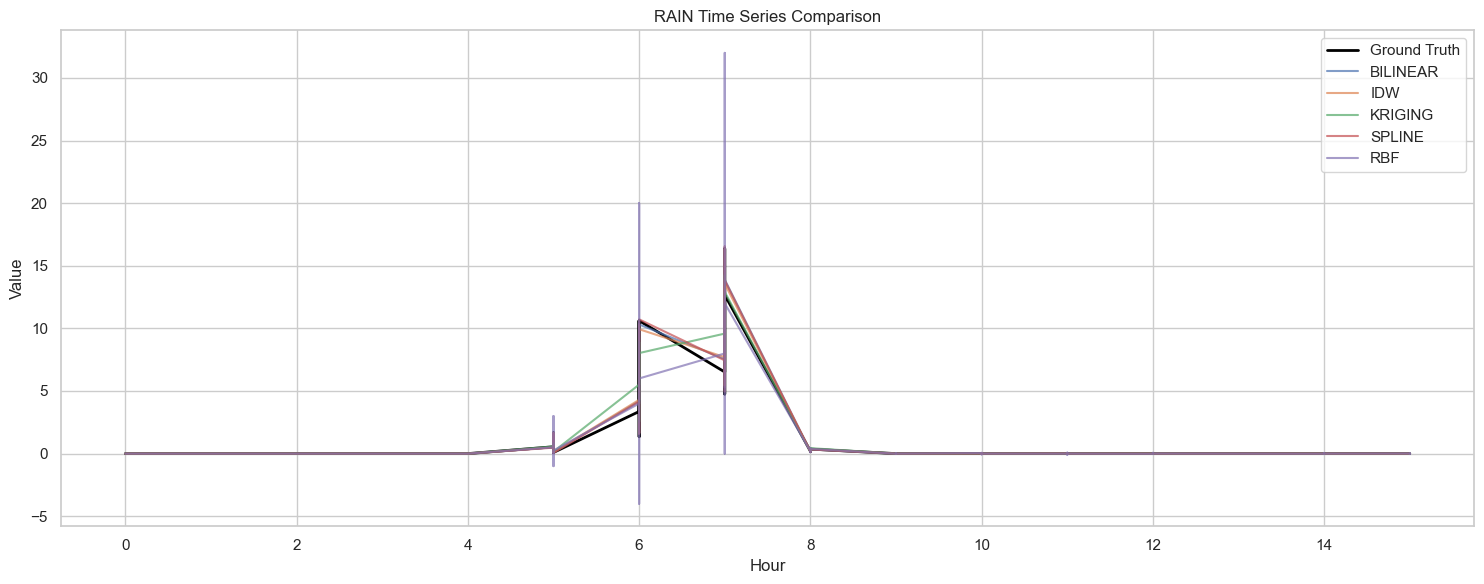


3. Statistical Tests:

BILINEAR:
KS-test: statistic=0.0396, p-value=0.0000
Mann-Whitney U test: statistic=2098272520.5000, p-value=0.0000

IDW:
KS-test: statistic=0.0602, p-value=0.0000
Mann-Whitney U test: statistic=2074506854.0000, p-value=0.0000

KRIGING:
KS-test: statistic=0.1303, p-value=0.0000
Mann-Whitney U test: statistic=1993680386.0000, p-value=0.0000

SPLINE:
KS-test: statistic=0.0721, p-value=0.0000
Mann-Whitney U test: statistic=2131718169.0000, p-value=0.0126

RBF:
KS-test: statistic=0.0574, p-value=0.0000
Mann-Whitney U test: statistic=2262628827.0000, p-value=0.0000


In [35]:
def time_series_analysis(results_df, methods=['bilinear', 'idw', 'kriging', 'spline', 'rbf']):
    """
    对真实值和插值结果进行时间序列比较分析
    """
    for param in ['wind_u', 'wind_v', 'rain']:
        print(f"\n{param.upper()} Time Series Analysis:")
        param_data = results_df[results_df['parameter'] == param]
        
        # 获取时间序列数据
        truth_data = param_data[param_data['method'] == 'ground_truth']
        
        # 1. 基本统计量分析
        print("\n1. Basic Statistics:")
        print("Ground Truth:")
        print(f"Max: {truth_data['value'].max():.4f}")
        print(f"Min: {truth_data['value'].min():.4f}")
        print(f"Mean: {truth_data['value'].mean():.4f}")
        print(f"Std: {truth_data['value'].std():.4f}")
        
        # 找出峰值时间点
        peak_idx = truth_data['value'].idxmax()
        trough_idx = truth_data['value'].idxmin()
        peak_time = truth_data.loc[peak_idx, 'hour']
        trough_time = truth_data.loc[trough_idx, 'hour']
        
        print(f"\nPeak Time: {peak_time}")
        print(f"Trough Time: {trough_time}")
        
        # 2. 各方法的峰值分析
        print("\n2. Peak Analysis by Method:")
        for method in methods:
            method_data = param_data[param_data['method'] == method]
            
            print(f"\n{method.upper()}:")
            print(f"Max: {method_data['value'].max():.4f}")
            print(f"Min: {method_data['value'].min():.4f}")
            print(f"Mean: {method_data['value'].mean():.4f}")
            print(f"Std: {method_data['value'].std():.4f}")
            
            method_peak_idx = method_data['value'].idxmax()
            method_trough_idx = method_data['value'].idxmin()
            method_peak_time = method_data.loc[method_peak_idx, 'hour']
            method_trough_time = method_data.loc[method_trough_idx, 'hour']
            
            print(f"Peak Time: {method_peak_time}")
            print(f"Trough Time: {method_trough_time}")
            
            peak_error = (method_data['value'].max() - truth_data['value'].max()) / truth_data['value'].max() * 100
            trough_error = (method_data['value'].min() - truth_data['value'].min()) / (abs(truth_data['value'].min()) + 1e-10) * 100
            
            print(f"Peak Value Error (%): {peak_error:.2f}")
            print(f"Trough Value Error (%): {trough_error:.2f}")
        
        # 3. 时间序列可视化
        plt.figure(figsize=(15, 6))
        
        # 绘制真实值
        plt.plot(truth_data['hour'], truth_data['value'], 
                label='Ground Truth', linewidth=2, color='black')
        
        # 绘制各方法结果
        for method in methods:
            method_data = param_data[param_data['method'] == method]
            plt.plot(method_data['hour'], method_data['value'], 
                    label=method.upper(), alpha=0.7)
        
        plt.title(f'{param.upper()} Time Series Comparison')
        plt.xlabel('Hour')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # 4. 统计显著性检验
        print("\n3. Statistical Tests:")
        for method in methods:
            method_data = param_data[param_data['method'] == method]
            
            # Kolmogorov-Smirnov检验
            ks_stat, ks_p = stats.ks_2samp(truth_data['value'], method_data['value'])
            
            # Mann-Whitney U检验
            mw_stat, mw_p = stats.mannwhitneyu(truth_data['value'], method_data['value'])
            
            print(f"\n{method.upper()}:")
            print(f"KS-test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")
            print(f"Mann-Whitney U test: statistic={mw_stat:.4f}, p-value={mw_p:.4f}")

# 执行时间序列分析
time_series_analysis(results_df)